# Heart Disease Prediction Model
 This project uses machine learning to predict the presence of heart disease using clinical data.

# Importing libraries 
We import all necessary libraries for data analysis, visualizatiion and machine learning.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
df = pd.read_csv('heart.csv')
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


The dataset contains 918 patient records with 12 clinical features used to predict heart diseases.

In [47]:
df.shape

(918, 12)

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [49]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [50]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


- Dataset has 918 rows and 12 columns
- No missing values observed

# Target Distribution
Checking how many patients have heart disease(1) compared to patients with no heart disease(0)


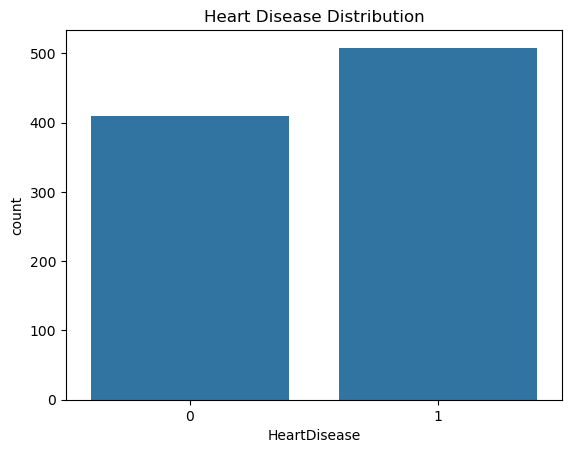

In [51]:
sns.countplot(x="HeartDisease", data=df)
plt.title("Heart Disease Distribution")
plt.show()

- 508 patients diagnosed with heart disease
- 410 patients with no heart disease

In [52]:
df['Sex'] = df['Sex'].map({'M': 1, 'F': 0})
categorical_cols= df.select_dtypes(include='object').columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

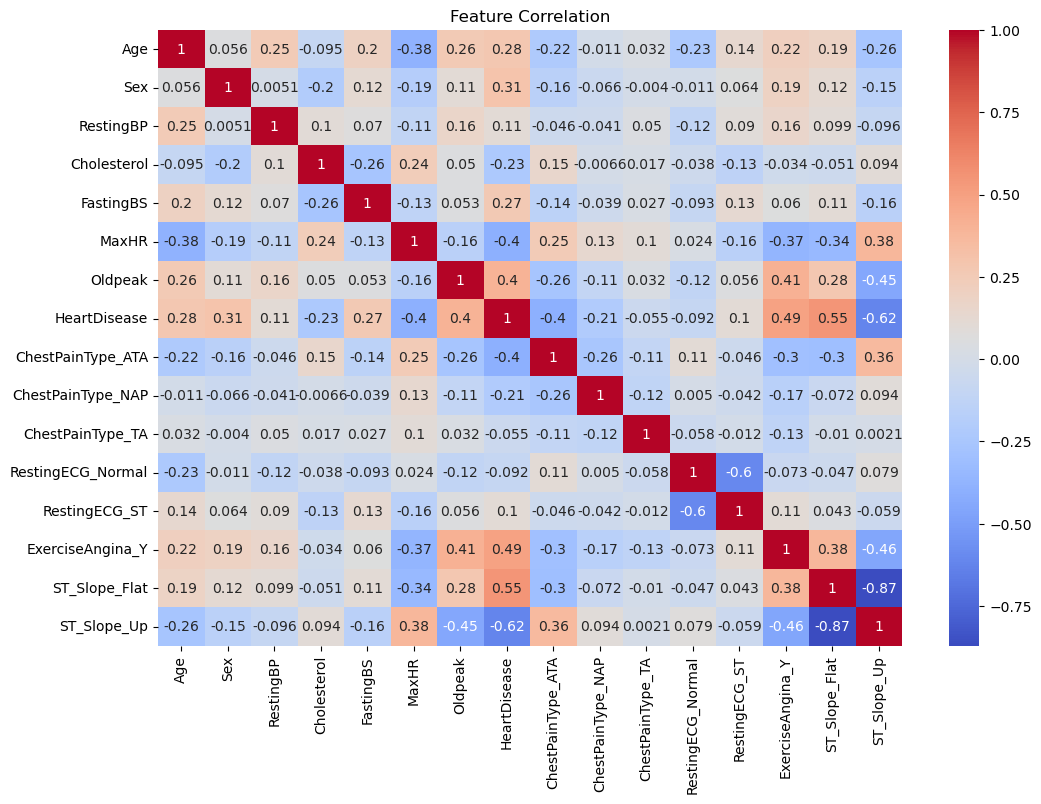

In [53]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

### 3.2 Feature Correlation
Analyzing how each feature correlates with heart disease.

**My findings:**
- ST_Slope_Flat has strong positive correlation (0.55)
- ExerciseAngina strongly correlates with disease (0.49)
- MaxHR has negative correlation (-0.4) — lower max heart rate indicates higher risk
- Oldpeak positively correlates (0.4) — higher ST depression = more risk

##  Model Training
We use a **Random Forest Classifier** : an ensemble method 
that builds multiple decision trees and combines their 
predictions for better accuracy.

**Why Random Forest?**
- Handles both numerical and categorical data well
- Resistant to overfitting
- Works well with medical datasets
- Provides feature importance insights

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score 
import pickle

In [55]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

In [56]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

In [57]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [58]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")


Accuracy: 86.96%


In [59]:
df['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

<Axes: >

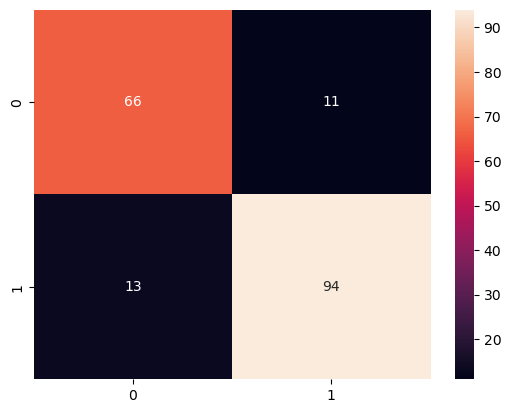

In [60]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

## Model Evaluation
Evaluating model performance using accuracy score 
and confusion matrix.

**Results:**
- Overall Accuracy: **86.96%**
- True Positives (Correct Disease Detection): **94**
- True Negatives (Correct No Disease): **66**
- False Positives: **11**
- False Negatives: **13**

The model is better at detecting actual heart disease cases 
which is the desired behaviour for a medical prediction tool.

##  Saving the Model
Saving the trained model using pickle so it can be 
loaded by our Streamlit web application.

In [61]:
pickle.dump(model, open("heart_model.pkl", "wb"))
pickle.dump(X.columns.tolist(), open("columns.pkl", "wb"))
print("Model and columns saved!")

Model and columns saved!


## In Summary
- I Successfully built a heart disease prediction model with **86.96% accuracy**
- Key risk factors I identified: ST Slope, Exercise Angina, Oldpeak, MaxHR
- Model saved and deployed as a web application using Streamlit
- Users can input their clinical measurements and get an instant risk assessment

##  My Next Step:
- Collect more patient data to improve accuracy
- Add more models and compare performance
- Integrate with medical APIs for real-time data